This notebook contains the data analysis for digital heaalth startups in Nigeria aimed at answering ecosysyteem questions and providing insights for investors and main system players.

In [206]:
# ============================================================
# NIGERIA HEALTHTECH ECOSYSTEM MAPPING
# Iyashi Health - Ecosystem Analysis
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 150)

# File path
file_path = "Iyashi_GroupB.xlsx"

# Load data
df = pd.read_excel(file_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (113, 8)

Columns:
['Start-Up Name', 'Year Founded', 'Headquarters', 'Founders', 'Websites', 'Operating status', 'Sector', 'Health Problem']


,Start-Up Name,Year Founded,Headquarters,Founders,Websites,Operating status,Sector,Health Problem
0,54gene,2019.0,Lagos,Dr. Abasi Ene-Obong,54gene.com,Inactive,Health Analytics,Limited access to genomic data for Africans. Improving disease research & personalized medicine.
1,AfriHealth,2018.0,Lagos,Linda Obi & Jude Chikezie,afri-health.io,Active,"Hospital Management, Supply Chain","Pharmaceutical Supply Chain & Services, hospital manageement"
2,AfyACare,2019.0,Lagos,Tosin Runsewe and Kola Oni,https://afya.care/,Active,Hospital Management,Health Management
3,AGCNigeria,2015.0,Lagos,Olaniyi T-Ralph & Ajayi Paul,https://agcnigeria.org/,Inactive,Medical Devices,drug interactions identification
4,Advantage Health Africa (AHA),2017.0,Lagos,Abimbola Adebakin,https://advantagehealthafrica.com/,Active,"Digital Pharmacy, Supply Chain",Pharmaceutical Supply Chain & Services


In [207]:
# ============================================================
# DATA QUALITY CHECK
# ============================================================

print("Number of startups:", len(df))
print("Number of variables:", len(df.columns))

print("\nMissing values:")
missing = pd.DataFrame({
    "Missing": df.isna().sum(),
    "Percentage": (df.isna().sum() / len(df) * 100).round(1)
})

display(missing)

print("\nDuplicate startup names:")
print(df["Start-Up Name"].duplicated().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Number of startups: 113
Number of variables: 8

Missing values:


,Missing,Percentage
Start-Up Name,0,0.0
Year Founded,3,2.7
Headquarters,1,0.9
Founders,4,3.5
Websites,9,8.0
Operating status,0,0.0
Sector,0,0.0
Health Problem,16,14.2



Duplicate startup names:
0

Duplicate rows:
0


In [208]:
# ============================================================
# STANDARDISE COLUMN NAMES
# ============================================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

df.columns

Index(['start_up_name', 'year_founded', 'headquarters', 'founders', 'websites',
       'operating_status', 'sector', 'health_problem'],
      dtype='object')

In [209]:
# ============================================================
# CLEAN STARTUP NAMES
# ============================================================

df["start_up_name"] = (
    df["start_up_name"]
    .astype(str)
    .str.strip()
)

# Check duplicate names
duplicate_names = (
    df[df["start_up_name"].duplicated(keep=False)]
    .sort_values("start_up_name")
)

display(duplicate_names)

,start_up_name,year_founded,headquarters,founders,websites,operating_status,sector,health_problem


In [210]:
# ============================================================
# CLEAN OPERATING STATUS
# ============================================================

def clean_status(x):
    if pd.isna(x):
        return "Unverified"
    
    x = str(x).strip().lower()
    
    if "inactive" in x:
        return "Inactive"
    
    if "active" in x:
        return "Active"
    
    if x in ["?", "unknown", "n/a", "na", ""]:
        return "Unverified"
    
    return "Unverified"


df["operating_status_clean"] = df["operating_status"].apply(clean_status)

status_summary = (
    df["operating_status_clean"]
    .value_counts()
    .rename_axis("Status")
    .reset_index(name="Startups")
)

status_summary["Percentage"] = (
    status_summary["Startups"] / len(df) * 100
).round(1)

display(status_summary)

,Status,Startups,Percentage
0,Active,100,88.5
1,Inactive,13,11.5


In [211]:
active = (df["operating_status_clean"] == "Active").sum()
inactive = (df["operating_status_clean"] == "Inactive").sum()
unverified = (df["operating_status_clean"] == "Unverified").sum()

known_status = active + inactive

print(f"Total startups: {len(df)}")
print(f"Active: {active} ({active/len(df)*100:.1f}%)")
print(f"Inactive: {inactive} ({inactive/len(df)*100:.1f}%)")
print(f"Unverified: {unverified} ({unverified/len(df)*100:.1f}%)")

if known_status > 0:
    print(
        f"Active among startups with known status: "
        f"{active/known_status*100:.1f}%"
    )

Total startups: 113
Active: 100 (88.5%)
Inactive: 13 (11.5%)
Unverified: 0 (0.0%)
Active among startups with known status: 88.5%


In [212]:
# ============================================================
# CLEAN FOUNDING YEAR
# ============================================================

df["year_founded_clean"] = pd.to_numeric(
    df["year_founded"],
    errors="coerce"
)

print("Known founding years:", df["year_founded_clean"].notna().sum())
print("Missing founding years:", df["year_founded_clean"].isna().sum())

display(
    df["year_founded_clean"]
    .describe()
)

Known founding years: 110
Missing founding years: 3


count     110.000000
mean     2019.290909
std         3.271634
min      2004.000000
25%      2017.000000
50%      2020.000000
75%      2021.750000
max      2025.000000
Name: year_founded_clean, dtype: float64

In [213]:
# ============================================================
# FOUNDING PERIODS
# ============================================================

def founding_period(year):
    if pd.isna(year):
        return "Unknown"
    elif year < 2010:
        return "2004–2009"
    elif year < 2015:
        return "2010–2014"
    elif year < 2020:
        return "2015–2019"
    elif year <= 2024:
        return "2020–2024"
    else:
        return "2025+"


df["founding_period"] = df["year_founded_clean"].apply(founding_period)

period_order = [
    "2004–2009",
    "2010–2014",
    "2015–2019",
    "2020–2024",
    "2025+",
    "Unknown"
]

period_summary = (
    df["founding_period"]
    .value_counts()
    .reindex(period_order, fill_value=0)
    .rename_axis("Founding Period")
    .reset_index(name="Startups")
)

period_summary["Percentage"] = (
    period_summary["Startups"] / len(df) * 100
).round(1)

display(period_summary)

,Founding Period,Startups,Percentage
0,2004–2009,2,1.8
1,2010–2014,3,2.7
2,2015–2019,48,42.5
3,2020–2024,54,47.8
4,2025+,3,2.7
5,Unknown,3,2.7


In [214]:
# ============================================================
# STARTUPS FOUNDED BY YEAR
# ============================================================

annual_founding = (
    df[df["year_founded_clean"].notna()]
    .groupby("year_founded_clean")
    .size()
    .reset_index(name="Startups")
)

annual_founding["year_founded_clean"] = (
    annual_founding["year_founded_clean"].astype(int)
)

display(annual_founding)

,year_founded_clean,Startups
0,2004,1
1,2009,1
2,2012,1
3,2013,1
4,2014,1
5,2015,5
6,2016,8
7,2017,11
8,2018,11
9,2019,13


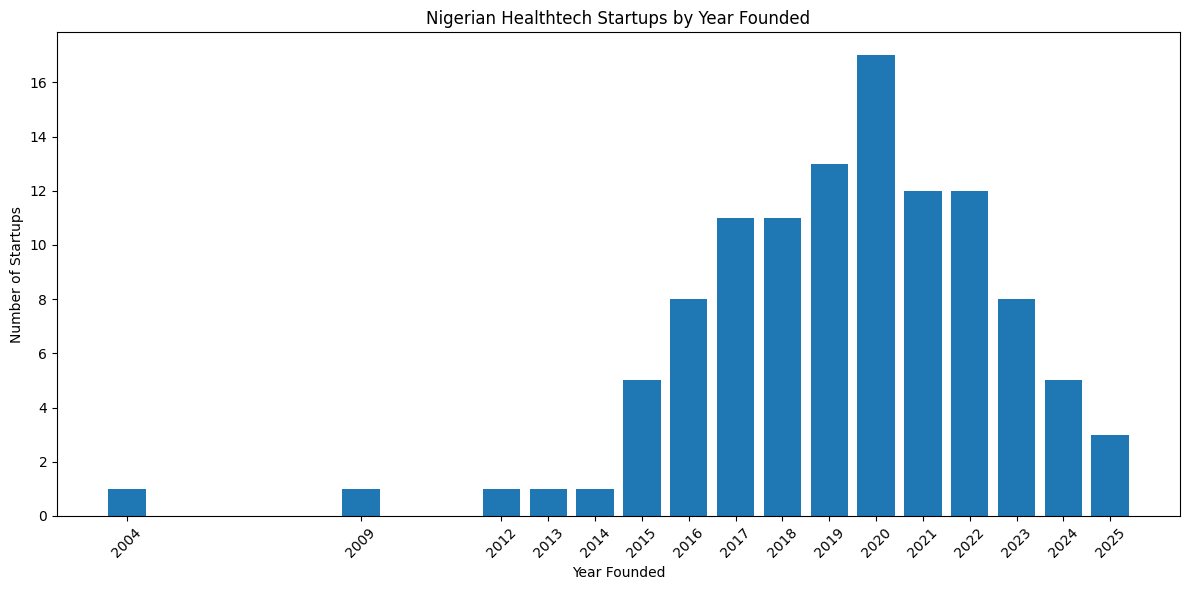

In [215]:
plt.figure(figsize=(12, 6))

plt.bar(
    annual_founding["year_founded_clean"],
    annual_founding["Startups"]
)

plt.title("Nigerian Healthtech Startups by Year Founded")
plt.xlabel("Year Founded")
plt.ylabel("Number of Startups")

plt.xticks(
    annual_founding["year_founded_clean"],
    rotation=45
)

plt.tight_layout()
plt.show()

In [216]:
# ============================================================
# CLEAN HEADQUARTERS
# ============================================================

df["headquarters_clean"] = (
    df["headquarters"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
)

display(
    df["headquarters_clean"]
    .value_counts()
    .head(30)
)

headquarters_clean
Lagos                81
Abuja                10
Abuja & Lagos         8
Lagos & London        2
Oyo State             2
Enugu                 1
Akwa Ibom State       1
Kano                  1
Abia State            1
Unknown               1
Oyo state             1
Benin City            1
Rivers State          1
Lagos & Amsterdam     1
Canada & Lagos        1
Name: count, dtype: int64

In [217]:
# ============================================================
# PRIMARY GEOGRAPHIC CATEGORISATION
# ============================================================

def classify_geography(x):
    if pd.isna(x):
        return "Unknown"
    
    x = str(x).lower().strip()
    
    if x in ["", "nan", "unknown", "n/a", "na"]:
        return "Unknown"
    
    has_lagos = "lagos" in x
    has_abuja = "abuja" in x
    
    # Both major hubs
    if has_lagos and has_abuja:
        return "Lagos & Abuja"
    
    if has_lagos:
        return "Lagos"
    
    if has_abuja:
        return "Abuja"
    
    # Explicit Nigeria but no specific city
    if "nigeria" in x:
        return "Nigeria - Location Unspecified"
    
    # International + Nigeria
    return "Other / International"


df["geography_category"] = df["headquarters_clean"].apply(
    classify_geography
)

geo_summary = (
    df["geography_category"]
    .value_counts()
    .rename_axis("Geography")
    .reset_index(name="Startups")
)

geo_summary["Percentage"] = (
    geo_summary["Startups"] / len(df) * 100
).round(1)

display(geo_summary)

,Geography,Startups,Percentage
0,Lagos,85,75.2
1,Abuja,10,8.8
2,Other / International,9,8.0
3,Lagos & Abuja,8,7.1
4,Unknown,1,0.9


In [218]:
# ============================================================
# GEOGRAPHIC CONCENTRATION
# ============================================================

known_geo = df[
    ~df["geography_category"].isin(["Unknown"])
]

lagos_count = (
    df["geography_category"]
    .isin(["Lagos", "Lagos & Abuja"])
    .sum()
)

abuja_count = (
    df["geography_category"]
    .isin(["Abuja", "Lagos & Abuja"])
    .sum()
)

print(
    f"Startups with Lagos presence: "
    f"{lagos_count} ({lagos_count/len(df)*100:.1f}%)"
)

print(
    f"Startups with Abuja presence: "
    f"{abuja_count} ({abuja_count/len(df)*100:.1f}%)"
)

Startups with Lagos presence: 93 (82.3%)
Startups with Abuja presence: 18 (15.9%)


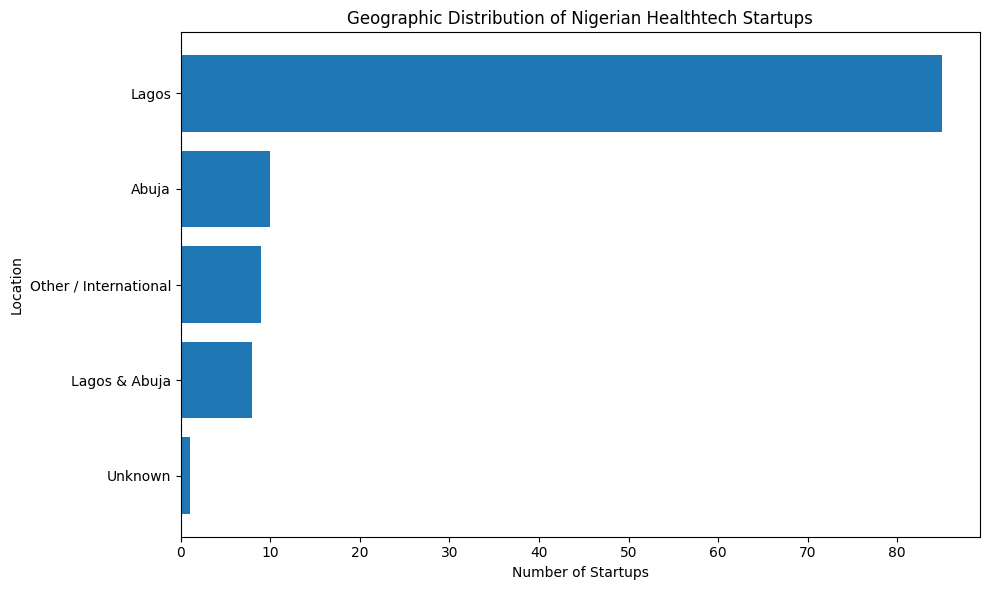

In [219]:
plt.figure(figsize=(10, 6))

geo_plot = geo_summary.sort_values("Startups")

plt.barh(
    geo_plot["Geography"],
    geo_plot["Startups"]
)

plt.title("Geographic Distribution of Nigerian Healthtech Startups")
plt.xlabel("Number of Startups")
plt.ylabel("Location")

plt.tight_layout()
plt.show()

In [220]:
# ============================================================
# CLEAN SECTOR FIELD
# ============================================================

df["sector_clean"] = (
    df["sector"]
    .fillna("")
    .astype(str)
    .str.strip()
)

display(
    df["sector_clean"]
    .value_counts()
)

sector_clean
Public Health                                                 12
Electronic Medical Records                                     9
Telemedicine                                                   8
Supply Chain                                                   7
Health Insurance                                               7
Medical Devices                                                6
Maternal & Child Health                                        6
Mental Health                                                  5
AI & Diagnostics                                               4
Digital Pharmacy                                               4
Health Financing                                               4
Health Analytics                                               3
AI & Diagnostics, Telemedicine                                 3
Emergency Care                                                 2
Emergency Care, Telemedicine                                   2
Supply Chain

In [221]:
# ============================================================
# STANDARDISE SECTOR TERMINOLOGY
# ============================================================

sector_replacements = {
    "ai and diagnostics": "AI & Diagnostics",
    "ai & diagnostic": "AI & Diagnostics",
    "diagnostics": "AI & Diagnostics",
    "telemedicine": "Telemedicine",
    "telehealth": "Telemedicine",
    "emr": "Electronic Medical Records",
    "electronic medical records": "Electronic Medical Records",
    "digital pharmacy": "Digital Pharmacy",
    "pharmacy": "Digital Pharmacy",
    "supply chain": "Supply Chain",
    "health analytics": "Health Analytics",
    "health insurance": "Health Insurance",
    "health financing": "Health Financing",
    "public health": "Public Health",
    "medical devices": "Medical Devices",
    "maternal & child health": "Maternal & Child Health",
    "maternal and child health": "Maternal & Child Health",
    "emergency care": "Emergency Care",
    "hospital management": "Hospital Management",
    "mental health": "Mental Health",
    "wellness": "Wellness",
    "healthtech": "Healthtech"
}

In [222]:
# ============================================================
# SECTOR KEYWORD MAPPING
# ============================================================

sector_keywords = {
    "AI & Diagnostics": [
        "ai",
        "artificial intelligence",
        "diagnostic",
        "diagnostics"
    ],
    
    "Telemedicine": [
        "telemedicine",
        "telehealth",
        "remote consultation"
    ],
    
    "Electronic Medical Records": [
        "emr",
        "electronic medical record",
        "electronic health record",
        "ehr"
    ],
    
    "Digital Pharmacy": [
        "digital pharmacy",
        "online pharmacy",
        "pharmacy"
    ],
    
    "Supply Chain": [
        "supply chain",
        "logistics",
        "medical supply"
    ],
    
    "Health Analytics": [
        "health analytics",
        "analytics",
        "health data"
    ],
    
    "Health Financing": [
        "health financing",
        "financing",
        "payments"
    ],
    
    "Health Insurance": [
        "health insurance",
        "insurance",
        "insurtech"
    ],
    
    "Public Health": [
        "public health",
        "population health"
    ],
    
    "Medical Devices": [
        "medical device",
        "medical devices",
        "device"
    ],
    
    "Maternal & Child Health": [
        "maternal",
        "child health",
        "maternal and child"
    ],
    
    "Emergency Care": [
        "emergency",
        "emergency care"
    ],
    
    "Hospital Management": [
        "hospital management",
        "hospital"
    ],
    
    "Mental Health": [
        "mental health",
        "mental wellness"
    ],
    
    "Wellness": [
        "wellness"
    ]
}


def extract_sectors(text):
    text = str(text).lower()
    
    found = []
    
    for sector, keywords in sector_keywords.items():
        if any(keyword in text for keyword in keywords):
            found.append(sector)
    
    # Preserve generic Healthtech if no more specific category is found
    if not found and "healthtech" in text:
        found.append("Healthtech")
    
    return found


df["sector_categories"] = df["sector_clean"].apply(
    extract_sectors
)

display(
    df[
        ["start_up_name", "sector_clean", "sector_categories"]
    ].head(20)
)

,start_up_name,sector_clean,sector_categories
0,54gene,Health Analytics,[Health Analytics]
1,AfriHealth,"Hospital Management, Supply Chain","[AI & Diagnostics, Supply Chain, Hospital Management]"
2,AfyACare,Hospital Management,[Hospital Management]
3,AGCNigeria,Medical Devices,[Medical Devices]
4,Advantage Health Africa (AHA),"Digital Pharmacy, Supply Chain","[AI & Diagnostics, Digital Pharmacy, Supply Chain]"
5,Akoma Health,Mental Health,[Mental Health]
6,All Purpose Medical Information System (APMIS),Health Analytics,[Health Analytics]
7,BabyMigo,Maternal & Child Health,[Maternal & Child Health]
8,Betacare,Telemedicine,[Telemedicine]
9,BetaLife Health,Emergency Care,[Emergency Care]


In [223]:
# ============================================================
# CREATE LONG-FORMAT SECTOR DATASET
# ============================================================

sector_long = df[
    ["start_up_name", "sector_categories"]
].explode("sector_categories")

sector_long = sector_long.rename(
    columns={"sector_categories": "sector_category"}
)

sector_long = sector_long[
    sector_long["sector_category"].notna()
]

display(sector_long.head(20))

,start_up_name,sector_category
0,54gene,Health Analytics
1,AfriHealth,AI & Diagnostics
1,AfriHealth,Supply Chain
1,AfriHealth,Hospital Management
2,AfyACare,Hospital Management
3,AGCNigeria,Medical Devices
4,Advantage Health Africa (AHA),AI & Diagnostics
4,Advantage Health Africa (AHA),Digital Pharmacy
4,Advantage Health Africa (AHA),Supply Chain
5,Akoma Health,Mental Health


In [224]:
# ============================================================
# SECTOR DISTRIBUTION
# ============================================================

sector_summary = (
    sector_long
    .groupby("sector_category")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="Startups")
)

sector_summary["Percentage of startups"] = (
    sector_summary["Startups"] / len(df) * 100
).round(1)

display(sector_summary)

,sector_category,Startups,Percentage of startups
0,AI & Diagnostics,32,28.3
1,Telemedicine,20,17.7
2,Supply Chain,16,14.2
3,Electronic Medical Records,14,12.4
4,Public Health,14,12.4
5,Health Analytics,9,8.0
6,Digital Pharmacy,9,8.0
7,Health Financing,8,7.1
8,Health Insurance,8,7.1
9,Maternal & Child Health,7,6.2


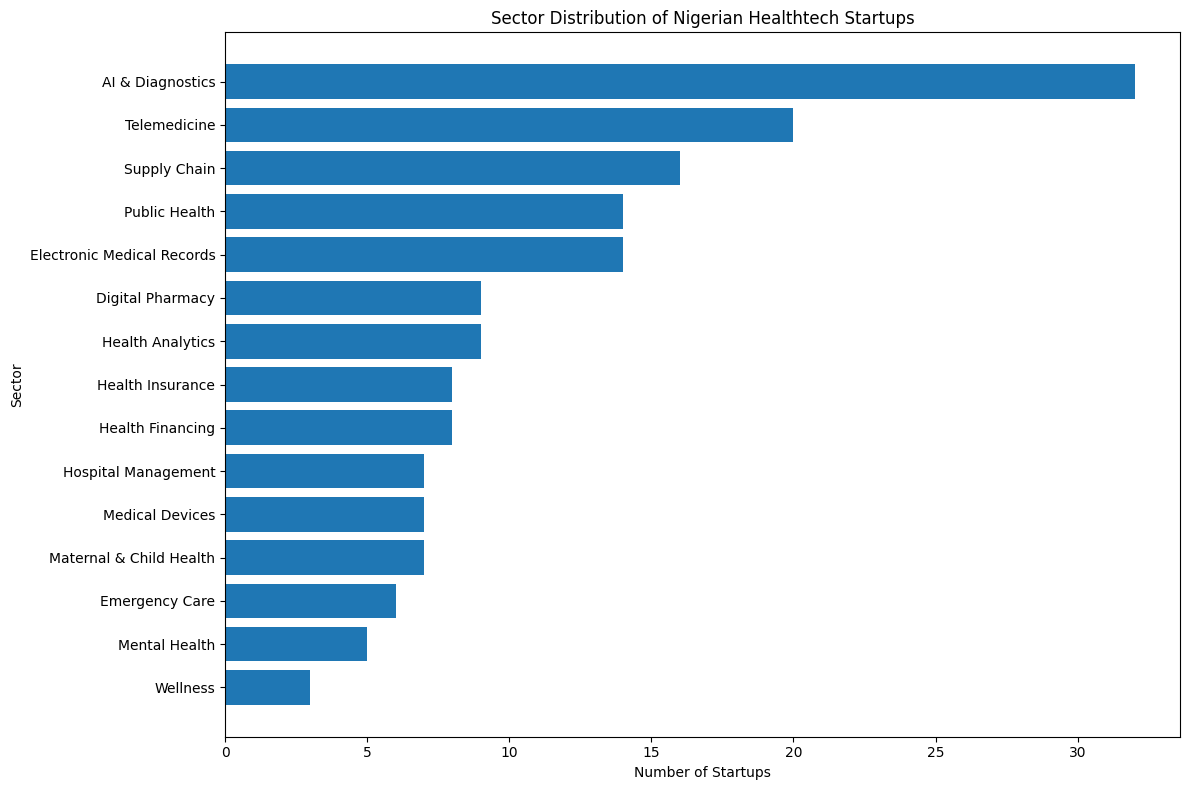

In [225]:
plt.figure(figsize=(12, 8))

plot_data = sector_summary.sort_values("Startups")

plt.barh(
    plot_data["sector_category"],
    plot_data["Startups"]
)

plt.title("Sector Distribution of Nigerian Healthtech Startups")
plt.xlabel("Number of Startups")
plt.ylabel("Sector")

plt.tight_layout()
plt.show()

In [226]:
# ============================================================
# HEALTH PROBLEM CLEANING
# ============================================================

df["health_problem_clean"] = (
    df["health_problem"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
)

In [227]:
# ============================================================
# HEALTH NEED CATEGORIES
# ============================================================

health_problem_keywords = {
    
    "Healthcare Access & Delivery": [
        "access",
        "healthcare delivery",
        "care delivery",
        "health services"
    ],
    
    "Diagnostics": [
        "diagnostic",
        "diagnostics",
        "testing",
        "screening"
    ],
    
    "Medication & Pharmacy Access": [
        "medication",
        "medicine",
        "pharmacy",
        "drug"
    ],
    
    "Maternal & Reproductive Health": [
        "maternal",
        "pregnancy",
        "reproductive",
        "fertility",
        "women"
    ],
    
    "Child Health": [
        "child",
        "paediatric",
        "pediatric",
        "children"
    ],
    
    "Mental Health": [
        "mental health",
        "depression",
        "anxiety",
        "psychological"
    ],
    
    "Chronic Disease": [
        "diabetes",
        "hypertension",
        "cardiovascular",
        "chronic",
        "cancer"
    ],
    
    "Infectious Disease & Public Health": [
        "infectious",
        "malaria",
        "hiv",
        "tb",
        "tuberculosis",
        "public health",
        "disease surveillance"
    ],
    
    "Emergency Care": [
        "emergency",
        "urgent care",
        "ambulance"
    ],
    
    "Health Financing": [
        "financing",
        "insurance",
        "payment",
        "cost",
        "affordability"
    ],
    
    "Healthcare Data & Information": [
        "data",
        "records",
        "information",
        "analytics"
    ],
    
    "Supply Chain & Logistics": [
        "supply chain",
        "logistics",
        "distribution"
    ]
}


def extract_health_needs(text):
    found = []
    
    for category, keywords in health_problem_keywords.items():
        if any(keyword in text for keyword in keywords):
            found.append(category)
    
    return found


df["health_need_categories"] = df[
    "health_problem_clean"
].apply(extract_health_needs)

health_long = df[
    ["start_up_name", "health_need_categories"]
].explode("health_need_categories")

health_long = health_long.rename(
    columns={"health_need_categories": "health_need"}
)

health_long = health_long[
    health_long["health_need"].notna()
]

health_summary = (
    health_long
    .groupby("health_need")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="Startups")
)

health_summary["Percentage"] = (
    health_summary["Startups"] / len(df) * 100
).round(1)

display(health_summary)

,health_need,Startups,Percentage
0,Healthcare Data & Information,17,15.0
1,Health Financing,16,14.2
2,Healthcare Access & Delivery,15,13.3
3,Medication & Pharmacy Access,14,12.4
4,Infectious Disease & Public Health,12,10.6
5,Diagnostics,9,8.0
6,Chronic Disease,8,7.1
7,Maternal & Reproductive Health,7,6.2
8,Mental Health,5,4.4
9,Supply Chain & Logistics,5,4.4


In [228]:
# ============================================================
# SECTOR × GEOGRAPHY
# ============================================================

sector_geo = (
    sector_long
    .merge(
        df[
            ["start_up_name", "geography_category"]
        ],
        on="start_up_name",
        how="left"
    )
)

sector_geo_table = pd.crosstab(
    sector_geo["sector_category"],
    sector_geo["geography_category"]
)

display(sector_geo_table)

geography_category,Abuja,Lagos,Lagos & Abuja,Other / International,Unknown
sector_category,,,,,
AI & Diagnostics,3,24,3,1,1
Digital Pharmacy,0,9,0,0,0
Electronic Medical Records,1,9,2,2,0
Emergency Care,0,4,2,0,0
Health Analytics,0,8,1,0,0
Health Financing,0,6,0,2,0
Health Insurance,1,7,0,0,0
Hospital Management,0,5,1,1,0
Maternal & Child Health,2,3,0,2,0


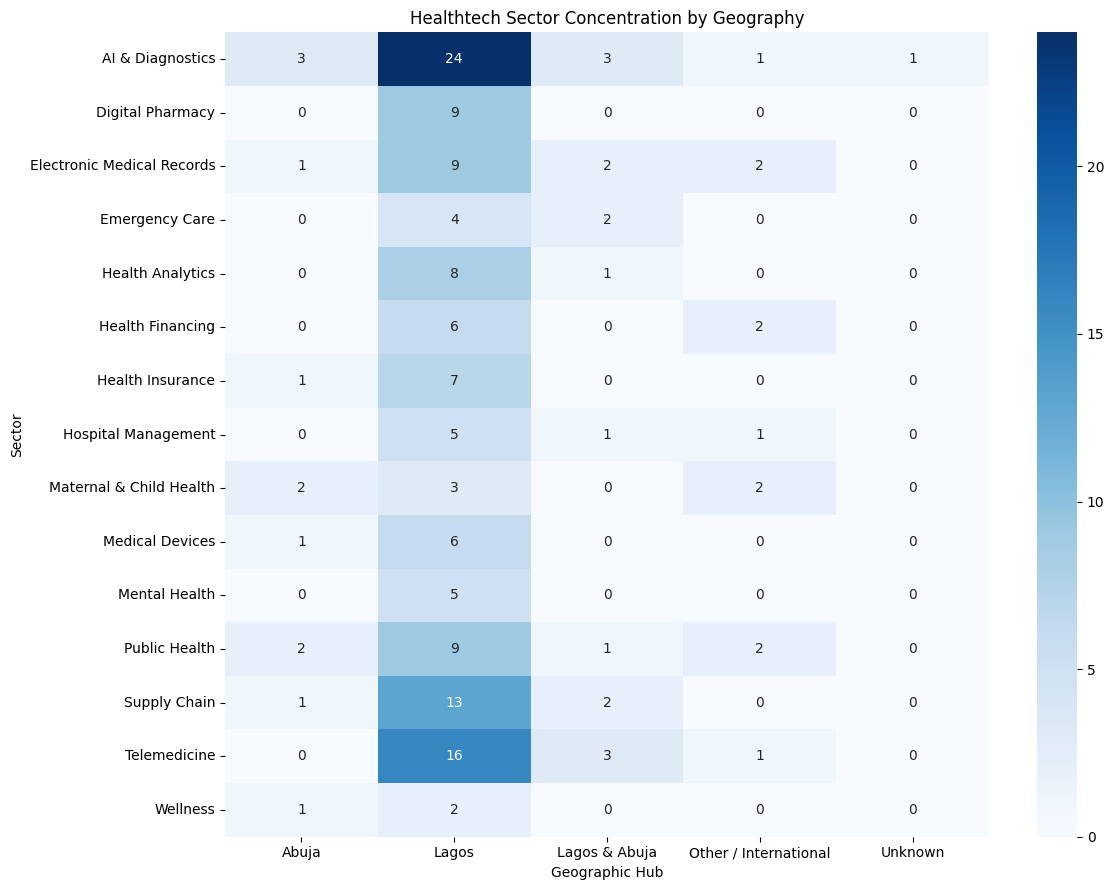

In [229]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    sector_geo_table,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Healthtech Sector Concentration by Geography")
plt.xlabel("Geographic Hub")
plt.ylabel("Sector")

plt.tight_layout()
plt.show()

In [230]:
# ============================================================
# SECTOR × OPERATING STATUS
# ============================================================

sector_status = (
    sector_long
    .merge(
        df[
            ["start_up_name", "operating_status_clean"]
        ],
        on="start_up_name",
        how="left"
    )
)

sector_status_table = pd.crosstab(
    sector_status["sector_category"],
    sector_status["operating_status_clean"]
)

display(sector_status_table)

operating_status_clean,Active,Inactive
sector_category,,
AI & Diagnostics,29,3
Digital Pharmacy,9,0
Electronic Medical Records,11,3
Emergency Care,6,0
Health Analytics,7,2
Health Financing,7,1
Health Insurance,8,0
Hospital Management,6,1
Maternal & Child Health,7,0


In [231]:
# ============================================================
# ACTIVE RATE BY SECTOR
# ============================================================

sector_status_table["Total"] = (
    sector_status_table.sum(axis=1)
)

sector_status_table["Active Rate (%)"] = (
    sector_status_table["Active"] /
    sector_status_table["Total"] * 100
).round(1)

display(
    sector_status_table
    .sort_values("Active Rate (%)", ascending=False)
)

operating_status_clean,Active,Inactive,Total,Active Rate (%)
sector_category,,,,
Digital Pharmacy,9,0,9,100.0
Health Insurance,8,0,8,100.0
Emergency Care,6,0,6,100.0
Wellness,3,0,3,100.0
Maternal & Child Health,7,0,7,100.0
Public Health,13,1,14,92.9
AI & Diagnostics,29,3,32,90.6
Telemedicine,18,2,20,90.0
Health Financing,7,1,8,87.5


In [232]:
# ============================================================
# FOUNDING PERIOD × GEOGRAPHY
# ============================================================

period_geo = pd.crosstab(
    df["founding_period"],
    df["geography_category"]
)

display(period_geo)

geography_category,Abuja,Lagos,Lagos & Abuja,Other / International,Unknown
founding_period,,,,,
2004–2009,0,2,0,0,0
2010–2014,0,3,0,0,0
2015–2019,3,39,3,3,0
2020–2024,6,37,5,5,1
2025+,1,2,0,0,0
Unknown,0,2,0,1,0


In [233]:
# ============================================================
# FOUNDING PERIOD × SECTOR
# ============================================================

period_sector = (
    sector_long
    .merge(
        df[
            ["start_up_name", "founding_period"]
        ],
        on="start_up_name",
        how="left"
    )
)

period_sector_table = pd.crosstab(
    period_sector["founding_period"],
    period_sector["sector_category"]
)

display(period_sector_table)

sector_category,AI & Diagnostics,Digital Pharmacy,Electronic Medical Records,Emergency Care,Health Analytics,Health Financing,Health Insurance,Hospital Management,Maternal & Child Health,Medical Devices,Mental Health,Public Health,Supply Chain,Telemedicine,Wellness
founding_period,,,,,,,,,,,,,,,
2004–2009,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0
2010–2014,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0
2015–2019,13,5,4,2,1,2,5,3,3,3,0,7,11,9,1
2020–2024,15,4,9,4,6,5,2,3,3,2,5,5,5,10,2
2025+,2,0,0,0,1,0,0,0,1,0,0,0,0,1,0
Unknown,2,0,0,0,0,1,1,1,0,0,0,1,0,0,0


In [234]:
# ============================================================
# SECTOR DIVERSIFICATION
# ============================================================

df["number_of_sectors"] = (
    df["sector_categories"]
    .apply(len)
)

sector_breadth = (
    df["number_of_sectors"]
    .value_counts()
    .sort_index()
    .rename_axis("Number of sectors")
    .reset_index(name="Startups")
)

sector_breadth["Percentage"] = (
    sector_breadth["Startups"] / len(df) * 100
).round(1)

display(sector_breadth)

,Number of sectors,Startups,Percentage
0,1,71,62.8
1,2,32,28.3
2,3,10,8.8


In [235]:
# proportion operating across multiple sectors
multi_sector = (
    df["number_of_sectors"] > 1
).sum()

print(
    f"Multi-sector startups: {multi_sector} "
    f"({multi_sector/len(df)*100:.1f}%)"
)

Multi-sector startups: 42 (37.2%)


In [236]:
# ============================================================
# DATA COMPLETENESS
# ============================================================

completeness = pd.DataFrame({
    "Variable": df.columns,
    "Missing": df.isna().sum().values,
})

completeness["Completeness (%)"] = (
    100 -
    completeness["Missing"] / len(df) * 100
).round(1)

display(completeness)

,Variable,Missing,Completeness (%)
0,start_up_name,0,100.0
1,year_founded,3,97.3
2,headquarters,1,99.1
3,founders,4,96.5
4,websites,9,92.0
5,operating_status,0,100.0
6,sector,0,100.0
7,health_problem,16,85.8
8,operating_status_clean,0,100.0
9,year_founded_clean,3,97.3


In [237]:
important_fields = [
    "start_up_name",
    "year_founded_clean",
    "headquarters_clean",
    "websites",
    "operating_status_clean",
    "sector_clean",
    "health_problem_clean"
]

data_quality = pd.DataFrame({
    "Field": important_fields,
    "Complete Records": [
        df[x].notna().sum()
        for x in important_fields
    ]
})

data_quality["Completeness (%)"] = (
    data_quality["Complete Records"] /
    len(df) * 100
).round(1)

display(data_quality)

,Field,Complete Records,Completeness (%)
0,start_up_name,113,100.0
1,year_founded_clean,110,97.3
2,headquarters_clean,113,100.0
3,websites,104,92.0
4,operating_status_clean,113,100.0
5,sector_clean,113,100.0
6,health_problem_clean,113,100.0


In [238]:
# ============================================================
# KEY ECOSYSTEM STATISTICS
# ============================================================

total = len(df)

active = (
    df["operating_status_clean"] == "Active"
).sum()

inactive = (
    df["operating_status_clean"] == "Inactive"
).sum()

unverified = (
    df["operating_status_clean"] == "Unverified"
).sum()

known_years = df[
    "year_founded_clean"
].notna().sum()

post_2015 = df[
    df["year_founded_clean"] >= 2015
].shape[0]

post_2015_known = df[
    df["year_founded_clean"].notna() &
    (df["year_founded_clean"] >= 2015)
].shape[0]

lagos = df[
    df["geography_category"].isin(
        ["Lagos", "Lagos & Abuja"]
    )
].shape[0]

abuja = df[
    df["geography_category"].isin(
        ["Abuja", "Lagos & Abuja"]
    )
].shape[0]

multi_sector = (
    df["number_of_sectors"] > 1
).sum()

key_stats = pd.DataFrame({
    "Metric": [
        "Total startups mapped",
        "Active startups",
        "Inactive startups",
        "Unverified startups",
        "Startups with known founding year",
        "Startups founded 2015 or later",
        "Startups with Lagos presence",
        "Startups with Abuja presence",
        "Multi-sector startups"
    ],
    
    "Value": [
        total,
        active,
        inactive,
        unverified,
        known_years,
        post_2015_known,
        lagos,
        abuja,
        multi_sector
    ]
})

key_stats["Percentage"] = [
    100,
    active/total*100,
    inactive/total*100,
    unverified/total*100,
    known_years/total*100,
    post_2015_known/known_years*100 if known_years else np.nan,
    lagos/total*100,
    abuja/total*100,
    multi_sector/total*100
]

key_stats["Percentage"] = key_stats[
    "Percentage"
].round(1)

display(key_stats)

,Metric,Value,Percentage
0,Total startups mapped,113,100.0
1,Active startups,100,88.5
2,Inactive startups,13,11.5
3,Unverified startups,0,0.0
4,Startups with known founding year,110,97.3
5,Startups founded 2015 or later,105,95.5
6,Startups with Lagos presence,93,82.3
7,Startups with Abuja presence,18,15.9
8,Multi-sector startups,42,37.2


In [239]:
# ============================================================
# CANDIDATE FINDINGS
# ============================================================

top_sector = sector_summary.iloc[0]

top_5_sectors = sector_summary.head(5)

candidate_findings = [
    {
        "Finding": "Ecosystem size",
        "Evidence": f"{total} startups were mapped.",
        "Statistic": f"n = {total}"
    },
    
    {
        "Finding": "Operating status",
        "Evidence": f"{active} startups were classified as active.",
        "Statistic": f"{active/total*100:.1f}% active"
    },
    
    {
        "Finding": "Geographic concentration",
        "Evidence": f"{lagos} startups have a Lagos presence.",
        "Statistic": f"{lagos/total*100:.1f}%"
    },
    
    {
        "Finding": "Secondary geographic hub",
        "Evidence": f"{abuja} startups have an Abuja presence.",
        "Statistic": f"{abuja/total*100:.1f}%"
    },
    
    {
        "Finding": "Ecosystem growth",
        "Evidence": f"{post_2015_known} of {known_years} startups with known founding year were founded from 2015 onward.",
        "Statistic": f"{post_2015_known/known_years*100:.1f}%"
    },
    
    {
        "Finding": "Sector concentration",
        "Evidence": f"{top_sector['sector_category']} is the most represented sector.",
        "Statistic": f"{int(top_sector['Startups'])} startups"
    },
    
    {
        "Finding": "Cross-sector activity",
        "Evidence": f"{multi_sector} startups operate across more than one mapped sector.",
        "Statistic": f"{multi_sector/total*100:.1f}%"
    }
]

candidate_findings_df = pd.DataFrame(candidate_findings)

display(candidate_findings_df)

,Finding,Evidence,Statistic
0,Ecosystem size,113 startups were mapped.,n = 113
1,Operating status,100 startups were classified as active.,88.5% active
2,Geographic concentration,93 startups have a Lagos presence.,82.3%
3,Secondary geographic hub,18 startups have an Abuja presence.,15.9%
4,Ecosystem growth,105 of 110 startups with known founding year were founded from 2015 onward.,95.5%
5,Sector concentration,AI & Diagnostics is the most represented sector.,32 startups
6,Cross-sector activity,42 startups operate across more than one mapped sector.,37.2%


In [240]:
# ============================================================
# REPORT-READY STATISTICS
# ============================================================

report_stats = pd.DataFrame({
    "Indicator": [
        "Startups mapped",
        "Active startups",
        "Inactive startups",
        "Unverified startups",
        "Lagos presence",
        "Abuja presence",
        "Founded 2015–2024",
        "Top sector",
        "Multi-sector startups"
    ],
    
    "Number": [
        total,
        active,
        inactive,
        unverified,
        lagos,
        abuja,
        df[
            df["year_founded_clean"].between(2015, 2024)
        ].shape[0],
        int(top_sector["Startups"]),
        multi_sector
    ]
})

report_stats["Percentage"] = [
    100,
    active/total*100,
    inactive/total*100,
    unverified/total*100,
    lagos/total*100,
    abuja/total*100,
    df[
        df["year_founded_clean"].between(2015, 2024)
    ].shape[0] / known_years * 100,
    top_sector["Startups"] / total * 100,
    multi_sector/total*100
]

report_stats["Percentage"] = report_stats[
    "Percentage"
].round(1)

display(report_stats)

,Indicator,Number,Percentage
0,Startups mapped,113,100.0
1,Active startups,100,88.5
2,Inactive startups,13,11.5
3,Unverified startups,0,0.0
4,Lagos presence,93,82.3
5,Abuja presence,18,15.9
6,Founded 2015–2024,102,92.7
7,Top sector,32,28.3
8,Multi-sector startups,42,37.2


In [241]:
# ============================================================
# EXPORT CLEANED DATA
# ============================================================

output_file = "Nigeria_Healthtech_Ecosystem_Cleaned.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    
    df.to_excel(
        writer,
        sheet_name="Cleaned Startups",
        index=False
    )
    
    status_summary.to_excel(
        writer,
        sheet_name="Operating Status",
        index=False
    )
    
    geo_summary.to_excel(
        writer,
        sheet_name="Geography",
        index=False
    )
    
    sector_summary.to_excel(
        writer,
        sheet_name="Sectors",
        index=False
    )
    
    health_summary.to_excel(
        writer,
        sheet_name="Health Needs",
        index=False
    )
    
    period_summary.to_excel(
        writer,
        sheet_name="Founding Period",
        index=False
    )
    
    report_stats.to_excel(
        writer,
        sheet_name="Key Statistics",
        index=False
    )

print(f"Saved: {output_file}")

Saved: Nigeria_Healthtech_Ecosystem_Cleaned.xlsx


In [242]:
# ============================================================
# CREATE CHART OUTPUT DIRECTORY
# ============================================================

chart_dir = Path("ecosystem_charts")
chart_dir.mkdir(exist_ok=True)

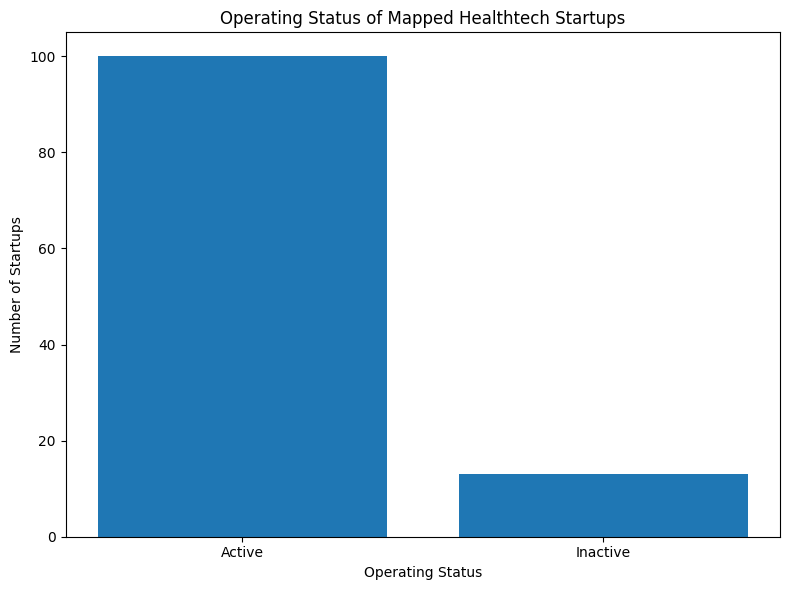

In [243]:
plt.figure(figsize=(8, 6))

plt.bar(
    status_summary["Status"],
    status_summary["Startups"]
)

plt.title("Operating Status of Mapped Healthtech Startups")
plt.xlabel("Operating Status")
plt.ylabel("Number of Startups")

plt.tight_layout()

plt.savefig(
    chart_dir / "operating_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

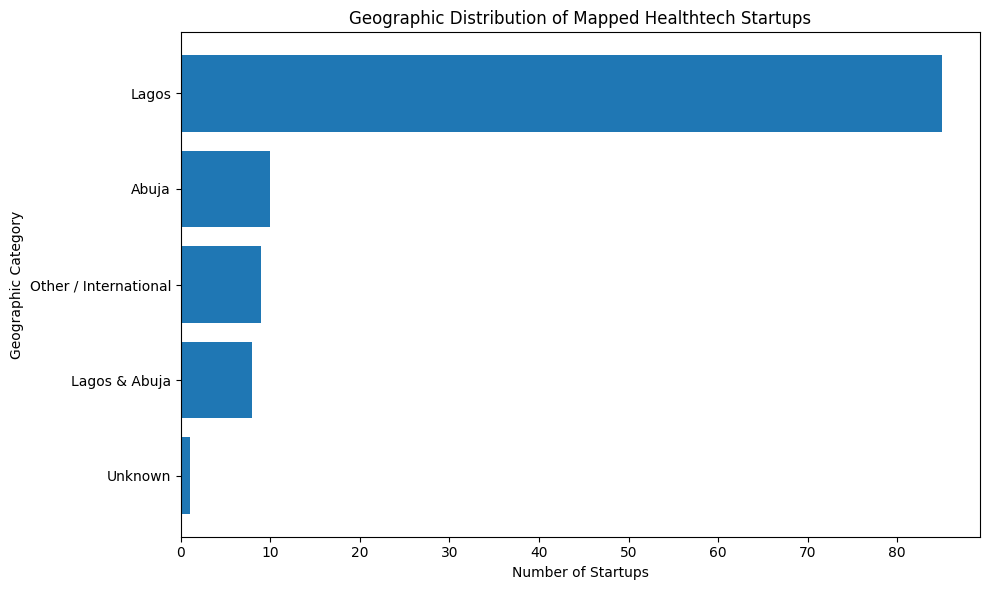

In [244]:
plt.figure(figsize=(10, 6))

geo_plot = geo_summary.sort_values("Startups")

plt.barh(
    geo_plot["Geography"],
    geo_plot["Startups"]
)

plt.title("Geographic Distribution of Mapped Healthtech Startups")
plt.xlabel("Number of Startups")
plt.ylabel("Geographic Category")

plt.tight_layout()

plt.savefig(
    chart_dir / "geographic_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

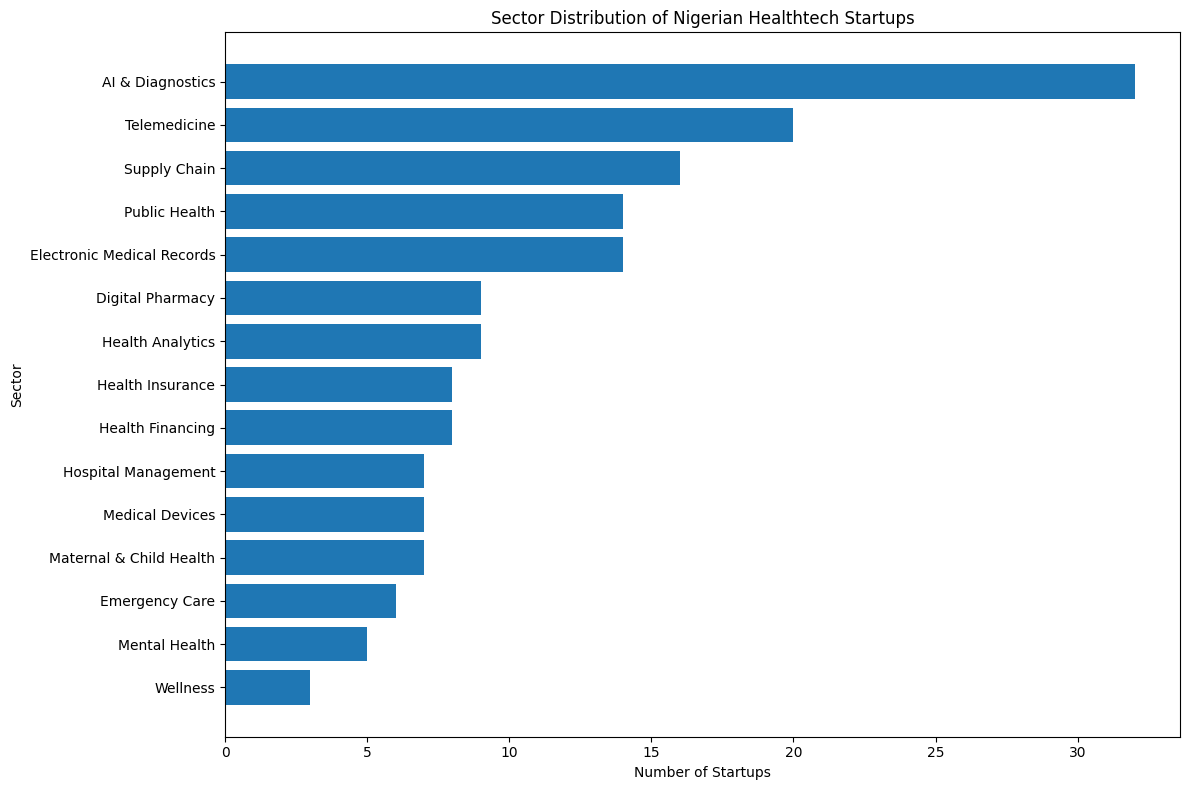

In [245]:
plt.figure(figsize=(12, 8))

sector_plot = sector_summary.sort_values("Startups")

plt.barh(
    sector_plot["sector_category"],
    sector_plot["Startups"]
)

plt.title("Sector Distribution of Nigerian Healthtech Startups")
plt.xlabel("Number of Startups")
plt.ylabel("Sector")

plt.tight_layout()

plt.savefig(
    chart_dir / "sector_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

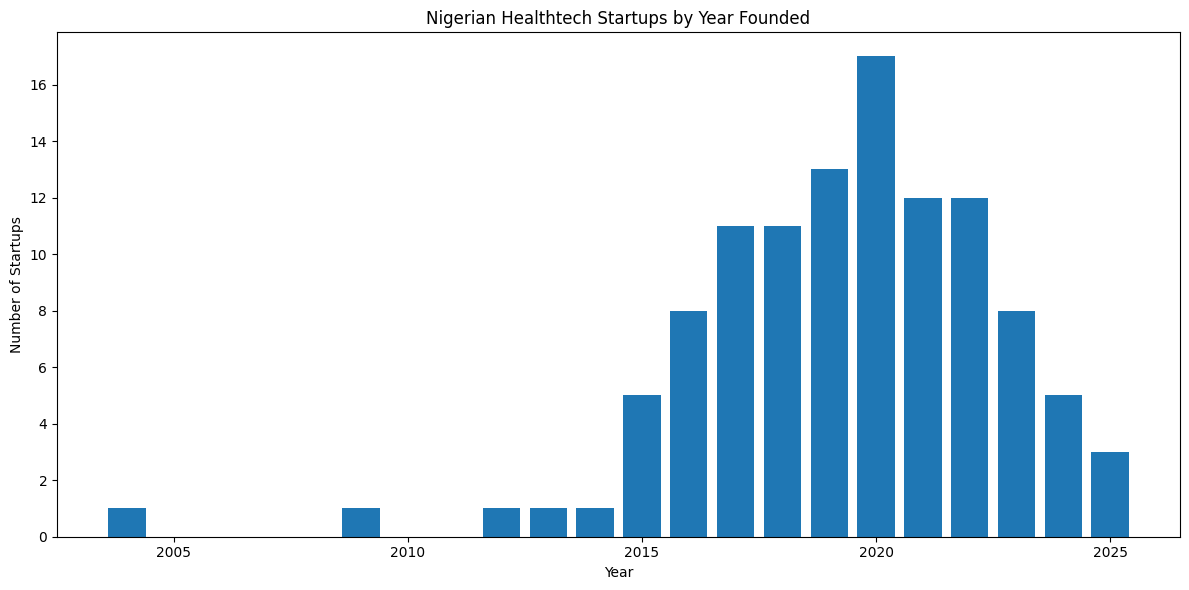

In [246]:
plt.figure(figsize=(12, 6))

plt.bar(
    annual_founding["year_founded_clean"],
    annual_founding["Startups"]
)

plt.title("Nigerian Healthtech Startups by Year Founded")
plt.xlabel("Year")
plt.ylabel("Number of Startups")

plt.tight_layout()

plt.savefig(
    chart_dir / "founding_year_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()